## Prep

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [9]:
# Import data
X_raw     = pd.read_excel('X_raw.xlsx',     index_col=0)
Y         = pd.read_excel('Y.xlsx',         index_col=0)
X_raw_val = pd.read_excel('X_raw_val.xlsx', index_col=0)
Y_val     = pd.read_excel('Y_val.xlsx',     index_col=0)

# Clean: drop missing values and align on common index
X_raw = X_raw.dropna()
Y     = Y.reindex(X_raw.index).dropna()
X_raw = X_raw.reindex(Y.index)

print(f"Training/test data:")
print(f"  X (features) : {X_raw.shape[0]} observations × {X_raw.shape[1]} features")
print(f"  Y (labels)   : {Y.shape[0]} observations × {Y.shape[1]} style(s)")
print(f"\nValidation data:")
print(f"  X_val        : {X_raw_val.shape[0]} observations × {X_raw_val.shape[1]} features")
print(f"  Y_val        : {Y_val.shape[0]} observations × {Y_val.shape[1]} style(s)")
print(f"\nFeature sample : {list(X_raw.columns[:6])} ...")
print(f"Label columns  : {list(Y.columns)}")
print()
print("Feature statistics:")
print(X_raw.describe().T[['mean','std','min','max']].round(4).head(10))

Training/test data:
  X (features) : 819 observations × 102 features
  Y (labels)   : 819 observations × 1 style(s)

Validation data:
  X_val        : 18 observations × 102 features
  Y_val        : 18 observations × 1 style(s)

Feature sample : ['gMom_3', 'gMom_6', 'gMom_9', 'gMom_12', 'gMom_15', 'gMom_18'] ...
Label columns  : [0]

Feature statistics:
           mean     std     min     max
gMom_3   0.0254  0.0776 -0.3863  0.3824
gMom_6   0.0508  0.1186 -0.4646  0.6001
gMom_9   0.0765  0.1480 -0.5328  0.7063
gMom_12  0.1017  0.1701 -0.5161  0.7404
gMom_15  0.1258  0.1871 -0.5739  0.7592
gMom_18  0.1498  0.2083 -0.5623  0.7242
gMom_21  0.1730  0.2302 -0.5789  1.0089
gMom_24  0.1957  0.2518 -0.5353  1.3070
gMom_27  0.2159  0.2672 -0.5218  1.3728
gMom_30  0.2351  0.2738 -0.5136  1.1909


In [11]:
# MinMax scaling
if Y.shape[1] == 1:
    y     = Y.iloc[:, 0]
    y_val = Y_val.iloc[:, 0]
    X     = X_raw.copy()
    X_v   = X_raw_val.copy()
else:
    y     = Y.stack().reset_index(drop=True)
    X     = pd.concat([X_raw] * Y.shape[1], ignore_index=True)
    y_val = Y_val.stack().reset_index(drop=True)
    X_v   = pd.concat([X_raw_val] * Y_val.shape[1], ignore_index=True)

print(f"Modelling arrays after alignment:")
print(f"  X : {X.shape}   y : {y.shape}")
print(f"  X_val : {X_v.shape}   y_val : {y_val.shape}")

scaler = MinMaxScaler()

Modelling arrays after alignment:
  X : (819, 102)   y : (819,)
  X_val : (18, 102)   y_val : (18,)


In [13]:
# Train split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Data partition:")
print(f"  Training set  : {X_train.shape[0]} observations  ({100*len(X_train)/len(X):.0f}%)")
print(f"  Test set      : {X_test.shape[0]}  observations  ({100*len(X_test)/len(X):.0f}%)")
print(f"  Validation    : {X_v.shape[0]} observations (held-out, never seen during training)")

# We need to scale after splitting - fit on training
X_train_sc = scaler.fit_transform(X_train)    # fit + transform training data
X_test_sc  = scaler.transform(X_test)         # transform only (no refit)
X_val_sc   = scaler.transform(X_v)            # transform only (no refit)

print(f"\nFeature scaling applied (MinMax, fit on train only).")
print(f"  Train range check — min: {X_train_sc.min():.2f}, max: {X_train_sc.max():.2f}")
print(f"  Test  range check — min: {X_test_sc.min():.4f}, max: {X_test_sc.max():.4f}")

Data partition:
  Training set  : 573 observations  (70%)
  Test set      : 246  observations  (30%)
  Validation    : 18 observations (held-out, never seen during training)

Feature scaling applied (MinMax, fit on train only).
  Train range check — min: 0.00, max: 1.00
  Test  range check — min: -0.1195, max: 1.3473


In [19]:
# Linear regression
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)

# Predict on each set
y_train_pred_lr = lr_model.predict(X_train_sc)
y_test_pred_lr  = lr_model.predict(X_test_sc)
y_val_pred_lr   = lr_model.predict(X_val_sc)

# MSE, RMSE, MAE
mse_train_lr  = mean_squared_error(y_train, y_train_pred_lr)
mse_test_lr   = mean_squared_error(y_test,  y_test_pred_lr)
mse_val_lr    = mean_squared_error(y_val,   y_val_pred_lr)
rmse_train_lr = np.sqrt(mse_train_lr)
rmse_test_lr  = np.sqrt(mse_test_lr)
rmse_val_lr   = np.sqrt(mse_val_lr)

mae_train_lr  = mean_absolute_error(y_train, y_train_pred_lr)
mae_test_lr   = mean_absolute_error(y_test,  y_test_pred_lr)
mae_val_lr    = mean_absolute_error(y_val,   y_val_pred_lr)

print("Linear Regression – Accuracy:")
print(f"  Train  MSE = {mse_train_lr:.6f}   RMSE = {rmse_train_lr:.6f}     MAE = {mae_train_lr:.6f}")
print(f"  Test   MSE = {mse_test_lr:.6f}   RMSE = {rmse_test_lr:.6f}     MAE = {mae_test_lr:.6f}")
print(f"  Val    MSE = {mse_val_lr:.6f}   RMSE = {rmse_val_lr:.6f}       MAE = {mae_val_lr:.6f}")

gap_lr = mse_test_lr - mse_train_lr

# Feature importance
coef_series = pd.Series(lr_model.coef_, index=X.columns)
print(f"\n  Top 10 features by |coefficient|:")
print(coef_series.abs().sort_values(ascending=False).head(10).round(4).to_string())

Linear Regression – Accuracy:
  Train  MSE = 0.000558   RMSE = 0.023613     MAE = 0.017483
  Test   MSE = 0.000761   RMSE = 0.027585     MAE = 0.020169
  Val    MSE = 0.001312   RMSE = 0.036225       MAE = 0.028973

  Top 10 features by |coefficient|:
eSD_30     0.2079
eSD_27     0.1350
eSD_36     0.1329
gBTA_27    0.1101
eMom_24    0.0954
gMom_21    0.0827
gSD_24     0.0807
gBTA_30    0.0750
gSD_30     0.0703
gSD_36     0.0675


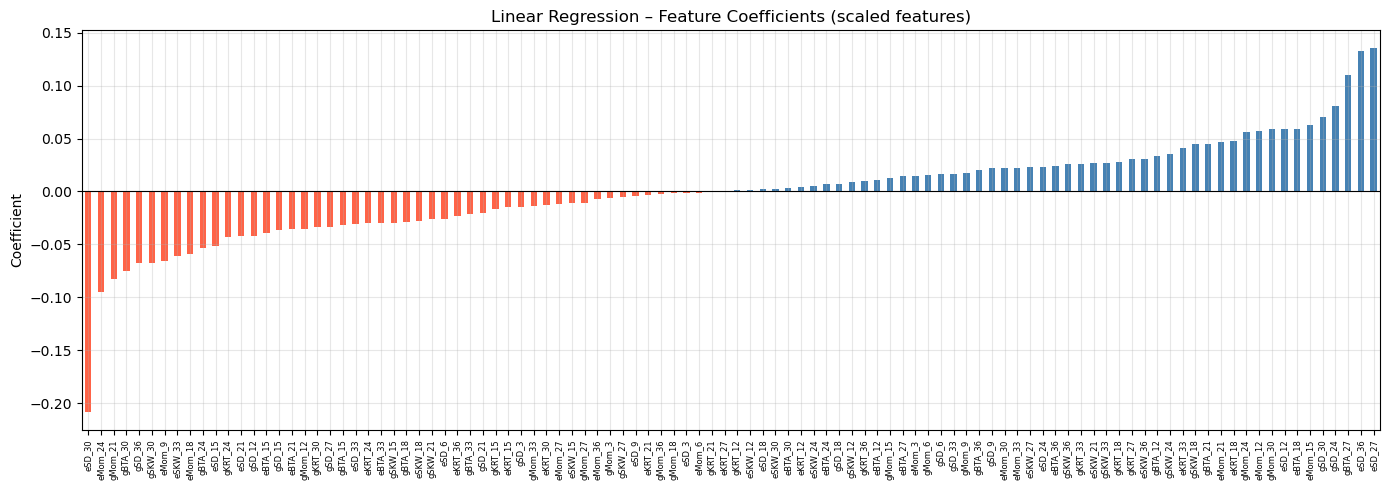

In [21]:
#  Feature coefficient bar chart 
fig, ax = plt.subplots(figsize=(14, 5))
coef_sorted = coef_series.sort_values()
coef_sorted.plot(kind='bar', ax=ax, color=['tomato' if c < 0 else 'steelblue' for c in coef_sorted])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression – Feature Coefficients (scaled features)', fontsize=12)
ax.set_ylabel('Coefficient')
ax.tick_params(axis='x', rotation=90, labelsize=6)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# Model 2: Ridge Regression with Parameter Optimisation (GridSearchCV)
ridge_param_grid = {
    'alpha'        : [1e-6, 1e-4, 1e-3, 0.01, 0.05, 0.1, 0.2, 0.5,
                      1, 2, 5, 10, 20, 50, 100],
    'fit_intercept': [True, False],
    'solver'       : ['auto', 'svd', 'cholesky']
}

ridge_gs = GridSearchCV(
    Ridge(),
    ridge_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
ridge_gs.fit(X_train_sc, y_train)
best_ridge = ridge_gs.best_estimator_

print("Ridge Regression – GridSearchCV Results:")
print(f"  Best parameters:")
for k, v in ridge_gs.best_params_.items():
    print(f"    {k}: {v}")
print(f"\n  Best CV MSE  : {-ridge_gs.best_score_:.6f}")
print(f"  Best CV RMSE : {np.sqrt(-ridge_gs.best_score_):.6f}")

Ridge Regression – GridSearchCV Results:
  Best parameters:
    alpha: 100
    fit_intercept: False
    solver: auto

  Best CV MSE  : 0.000702
  Best CV RMSE : 0.026502
